In [2]:
import numpy as np

import bot
import state
import physics
import presets
import nn
import scoring
import curling_nn
from constants import center_of_target_house, house_outer_circle_radius, STONE_RADIUS_M
import dataset


import logging

logging.basicConfig(level=logging.ERROR, format="%(message)s")
logger = logging.getLogger(__name__)
logging.getLogger('matplotlib.font_manager').setLevel(logging.WARNING)

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [3]:
neural_network = curling_nn.ValueNetwork(seed=0, num_stones_per_side=5)
loss_function = nn.SoftmaxCrossEntropyLoss()

In [4]:
# TODO: training data should have throws from both teams
seed_states = presets.random_sheet_states(
  team1=5,
  team2=4,
  # TODO: use grid for better training data? maybe pick out best throws
  num_sims=200,
)
num_stones_per_side = 5

throws, states = bot.RandomThrows(rng=np.random.default_rng(0), n_throws_to_generate=200).get_throws_for_num_sims(team=1, sheet_states=seed_states)

final_states = physics.run_until_stopping(sheet_states=state.add_stones_from_throws(states, throws))
final_scores = scoring.get_net_score_for_team(final_states, 0)

data = curling_nn.InputFeatures.create_score_match_dataset_from_sheet_states(
  states, throws, final_scores, num_stones_per_side
)


In [5]:
# TODO: partition from regular data, helper
validation_seed_states = presets.random_sheet_states(
  team1=5,
  team2=4,
  num_sims=100,
)
num_stones_per_side = 5

validation_throws, validation_states = bot.RandomThrows(rng=np.random.default_rng(0), n_throws_to_generate=100).get_throws_for_num_sims(team=1, sheet_states=validation_seed_states)

validation_final_states = physics.run_until_stopping(sheet_states=state.add_stones_from_throws(validation_states, validation_throws))
validation_final_scores = scoring.get_net_score_for_team(validation_final_states, 0)

validation_data = curling_nn.InputFeatures.create_score_match_dataset_from_sheet_states(
  validation_states, validation_throws, validation_final_scores, num_stones_per_side
)


## categorical score predictor

In [6]:
losses = []
num_points_per_batch = 100
num_iters = 10

for i in range(num_iters):
    lr = 1 * 0.5 * (1 + np.cos(np.pi * i / num_iters))
    for batch in data.shuffle_batches(num_points_per_batch, seed=None):
        neural_network.train_batched(
            batch,
            loss_function,
            lr,
            0,
        )

    losses.append(
        neural_network.get_average_loss_batched(
            data.input_features, data.answers, loss_function
        )
    )

In [7]:
validation_pred = neural_network.run(validation_data.input_features[:,:,None])

In [14]:
validation_r2 = (
    1
    - ((validation_data.answers - nn.softmax(validation_pred)[:, :, 0]) ** 2).sum()
    / (validation_data.answers**2).sum()
)

In [15]:
validation_r2

np.float64(0.07449398883131764)

Loaded backend module://matplotlib_inline.backend_inline version unknown.
Loaded backend module://matplotlib_inline.backend_inline version unknown.


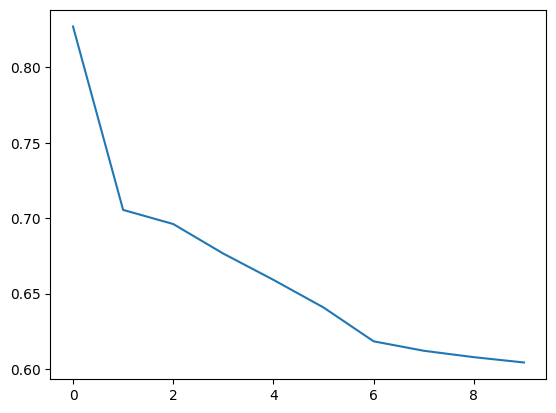

In [10]:
plt.plot(losses)

In [11]:
validation_loss = neural_network.get_average_loss_batched(
            validation_data.input_features, validation_data.answers, loss_function
        )
print(validation_loss)

2.031206268501989


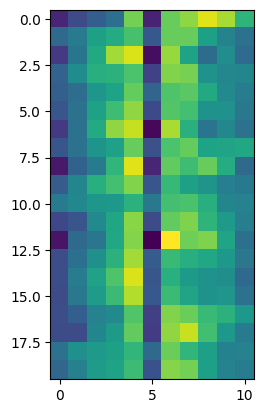

In [12]:
plt.imshow(neural_network.run(validation_data.input_features[:, :, None])[:20,:,0])

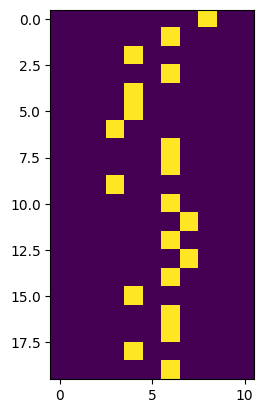

In [13]:
plt.imshow(validation_data.answers[:20,:])

## NEXT UP: predicting from second to last state